In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv("/Users/sharath/Documents/Data Science - Use Cases/Global Supply Chain Disruption/global_supply_chain_risk_2026.csv")

In [46]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [47]:
df.shape

(5000, 14)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [49]:
df.isnull().sum()

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df['Shipment_ID'].duplicated().sum()

np.int64(0)

In [52]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].min(), df['Date'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [53]:
df["Year"] = df['Date'].dt.year

In [54]:
df["Month"] = df['Date'].dt.month

In [55]:
df["Month_Name"] = df['Date'].dt.month_name()

In [56]:
df["Year_Month"] = df['Date'].dt.to_period("M")

In [57]:
df["Lead_Time_Days"].describe()

count    5000.000000
mean       19.355386
std        31.405143
min         0.500000
25%         2.110000
50%         8.245000
75%        21.207500
max       236.390000
Name: Lead_Time_Days, dtype: float64

In [58]:
df['Lead_Time_Days'].quantile([0.90,0.95,0.99])

0.90     51.5250
0.95     80.8115
0.99    169.8592
Name: Lead_Time_Days, dtype: float64

In [59]:
df['Lead_Time_Days']

0       41.39
1       40.92
2       11.54
3       53.13
4        0.50
        ...  
4995    20.28
4996     0.50
4997     4.41
4998    31.18
4999     1.43
Name: Lead_Time_Days, Length: 5000, dtype: float64

In [60]:
df["Lead_Time_Days"].skew()

np.float64(3.349222712647645)

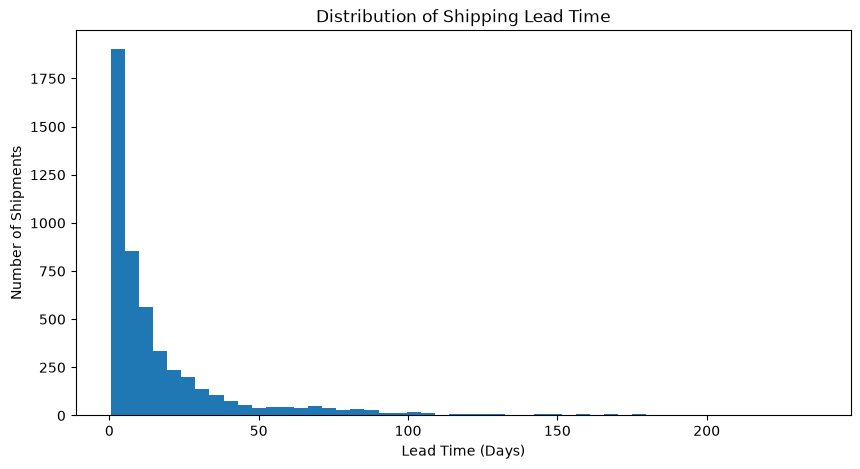

In [61]:
plt.figure(figsize=(10,5))
plt.hist(df["Lead_Time_Days"],bins=50)
plt.title("Distribution of Shipping Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Shipments")
plt.show()

In [62]:
df["Disruption_Occurred"].value_counts()

Disruption_Occurred
1    3063
0    1937
Name: count, dtype: int64

In [63]:
df["Disruption_Occurred"].value_counts(normalize=True) * 100

Disruption_Occurred
1    61.26
0    38.74
Name: proportion, dtype: float64

In [64]:
df.groupby("Disruption_Occurred")["Lead_Time_Days"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
Disruption_Occurred,,,,
0,1937,8.885183,6.24,9.926030
1,3063,25.976601,10.69,37.877449


In [65]:
Q1 = df["Lead_Time_Days"].quantile(0.25)
Q3 = df["Lead_Time_Days"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
upper_bound

np.float64(49.853750000000005)

In [66]:
lead_time_outliers = df[df["Lead_Time_Days"] > upper_bound]
len(lead_time_outliers)

518

In [67]:
lead_time_outliers["Disruption_Occurred"].value_counts(normalize=True) * 100

Disruption_Occurred
1    96.718147
0     3.281853
Name: proportion, dtype: float64

In [68]:
transport_analysis = (df.groupby("Transport_Mode").agg(
    Shipments = ("Shipment_ID", "count"),
    Disruption_Rate = ("Disruption_Occurred", "mean"),
    Avg_Lead_Time = ("Lead_Time_Days", "mean"),
    Median_Lead_Time = ("Lead_Time_Days", "median")
).reset_index()
)
transport_analysis["Disruption_Rate"] * 100
transport_analysis

,Transport_Mode,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
0,Air,1320,0.617424,1.644273,0.930
1,Rail,1185,0.611814,19.954253,11.540
2,Road,1214,0.610379,16.452306,9.295
3,Sea,1281,0.610461,39.802966,21.790


In [69]:
weather_analysis = (df.groupby("Weather_Condition").agg(
    Shipments = ("Shipment_ID", "count"),
    Disruption_Rate = ("Disruption_Occurred", "mean"),
    Avg_Lead_Time = ("Lead_Time_Days", "mean"),
    Median_Lead_Time = ("Lead_Time_Days", "median")
).reset_index()
)
weather_analysis["Disruption_Rate"] *= 100
weather_analysis.sort_values("Disruption_Rate", ascending=False)

,Weather_Condition,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
2,Hurricane,990,100.000000,53.501848,40.030
4,Storm,1002,79.540918,19.299182,14.725
1,Fog,1036,48.069498,9.892847,7.000
3,Rain,977,41.965200,7.736049,5.980
0,Clear,995,36.984925,6.698704,5.130


In [70]:
df["Geo_Risk_Quartile"] = pd.qcut(df["Geopolitical_Risk_Score"],q=4, duplicates="drop")

geo_analysis = (df.groupby("Geo_Risk_Quartile", observed=True).agg(
    Shipments = ("Shipment_ID", "count"),
    Disruption_Rate = ("Disruption_Occurred", "mean"),
    Avg_Lead_Time = ("Lead_Time_Days", "mean")
))

geo_analysis

,Shipments,Disruption_Rate,Avg_Lead_Time
Geo_Risk_Quartile,,,
"(-0.001, 2.6]",1260,0.457937,15.773675
"(2.6, 5.1]",1255,0.588845,18.800255
"(5.1, 7.5]",1256,0.662420,19.537492
"(7.5, 10.0]",1229,0.744508,23.408210


In [71]:
df["Carrier_Reliability_Quartile"] = pd.qcut(
    df["Carrier_Reliability_Score"],
    q=4
)
carrier_analysis = (
    df.groupby("Carrier_Reliability_Quartile",observed=True)
    .agg(
        Shipments=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Avg_Lead_Time=("Lead_Time_Days", "mean")
    )
)

carrier_analysis

,Shipments,Disruption_Rate,Avg_Lead_Time
Carrier_Reliability_Quartile,,,
"(0.499, 0.629]",1251,0.650679,19.503429
"(0.629, 0.757]",1257,0.651551,19.431583
"(0.757, 0.879]",1248,0.588942,19.771715
"(0.879, 1.0]",1244,0.558682,18.711849


In [72]:
risk_interaction = (df.groupby(["Weather_Condition", "Geo_Risk_Quartile"], observed = True).agg(
    Shipments = ("Shipment_ID", "count"),
    Disruption_Rate = ("Disruption_Occurred", "mean")
).reset_index())
risk_interaction["Disruption_Rate"] *= 100
risk_interaction

,Weather_Condition,Geo_Risk_Quartile,Shipments,Disruption_Rate
0,Clear,"(-0.001, 2.6]",259,19.691120
1,Clear,"(2.6, 5.1]",245,35.918367
2,Clear,"(5.1, 7.5]",256,42.578125
3,Clear,"(7.5, 10.0]",235,51.063830
4,Fog,"(-0.001, 2.6]",253,29.249012
5,Fog,"(2.6, 5.1]",265,41.132075
6,Fog,"(5.1, 7.5]",262,54.580153
7,Fog,"(7.5, 10.0]",256,67.187500
8,Hurricane,"(-0.001, 2.6]",246,100.000000
9,Hurricane,"(2.6, 5.1]",257,100.000000


In [73]:
df[["Distance_km", "Lead_Time_Days"]].corr()

,Distance_km,Lead_Time_Days
Distance_km,1.000000,0.335665
Lead_Time_Days,0.335665,1.000000


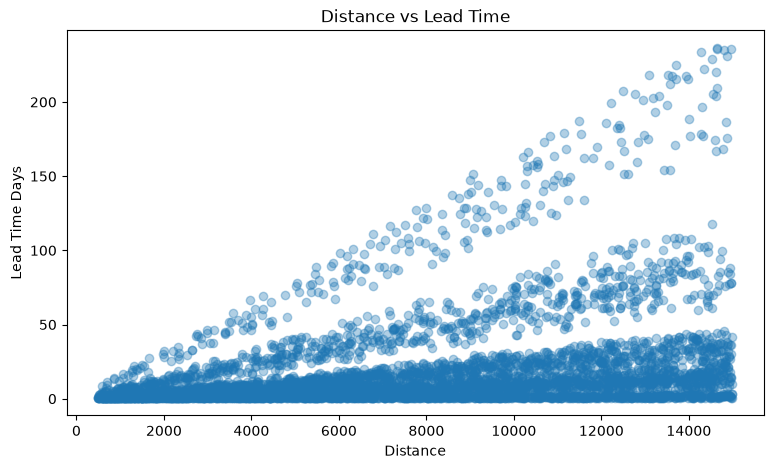

In [74]:
plt.figure(figsize=(9,5))
plt.scatter(df["Distance_km"], df["Lead_Time_Days"], alpha = 0.35)
plt.title("Distance vs Lead Time")
plt.xlabel("Distance")
plt.ylabel("Lead Time Days")
plt.show()

In [76]:
product_analysis = (df.groupby('Product_Category').agg(
    Shipments = ("Shipment_ID", "count"),
    Disruption_Rate = ("Disruption_Occurred", "mean"),
    Avg_Lead_Time = ("Lead_Time_Days", "mean"),
    Median_Lead_Time=("Lead_Time_Days", "median")
).reset_index())

product_analysis["Disruption_Rate"] *= 100
product_analysis.sort_values("Disruption_Rate", ascending=False)

,Product_Category,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
4,Textiles,1010,64.851485,20.096733,8.350
3,Pharmaceuticals,1006,61.133201,19.795736,8.865
0,Automotive,959,60.479666,18.980938,7.720
2,Perishables,1009,60.257681,20.131685,8.170
1,Electronics,1016,59.547244,17.764892,7.995


In [77]:
origin_analysis = (df.groupby("Origin_Port").agg(
    Shipments = ("Shipment_ID", "count"),
    Disruption_Rate = ("Disruption_Occurred", "mean"),
    Avg_Lead_Time = ("Lead_Time_Days", "mean"),
    Median_Lead_Time=("Lead_Time_Days", "median")
).reset_index())
origin_analysis["Disruption_Rate"] *= 100
origin_analysis.sort_values("Disruption_Rate", ascending=False)

,Origin_Port,Shipments,Disruption_Rate,Avg_Lead_Time,Median_Lead_Time
3,Hamburg,597,62.479062,20.071692,8.680
6,Shanghai,644,62.422360,21.361972,9.215
7,Singapore,599,62.270451,18.978781,7.880
0,Antwerp,635,61.417323,18.949795,8.310
2,Dubai,610,60.819672,17.011213,8.055
4,Los Angeles,602,60.299003,17.616113,7.375
1,Busan,667,60.269865,19.607976,8.200
5,Rotterdam,646,60.216718,21.014474,8.495
